In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn import tree
import warnings

In [76]:
le = LabelEncoder()

In [77]:
df_crop = pd.read_csv('../../dataset/dataset_yogyakarta_augmented.csv')

In [78]:
# df_crop.head()
# df_crop.tail()
df_crop.shape

(6291, 10)

In [79]:
df_crop.columns

Index(['temperature', 'humidity', 'rainfall', 'ph', 'nitrogen', 'phosphorous',
       'potassium', 'carbon', 'soil', 'label'],
      dtype='object')

In [80]:
df_crop['label'].unique()

array(['chives', 'peanut', 'muskmelon', 'orange', 'watermelon', 'coffee',
       'banana', 'garlic', 'cabbage', 'sweetpotato', 'tea', 'mango',
       'soybean', 'rice', 'papaya', 'shallots', 'maize', 'mungbean',
       'cassava', 'chilli'], dtype=object)

In [81]:
print(df_crop.isnull().sum())

temperature    0
humidity       0
rainfall       0
ph             0
nitrogen       0
phosphorous    0
potassium      0
carbon         0
soil           0
label          0
dtype: int64


In [82]:
print(df_crop.describe())

       temperature     humidity     rainfall           ph     nitrogen  \
count  6291.000000  6291.000000  6291.000000  6291.000000  6291.000000   
mean     27.026694    74.419282   123.684741     6.341078    65.708792   
std       3.926162    12.558060    64.943922     0.629462    31.401340   
min      10.816269    44.605275    18.942143     4.438439    12.010000   
25%      24.885522    64.106525    76.144142     6.073910    52.195000   
50%      27.009321    75.100000   108.849558     6.410767    60.241000   
75%      29.131326    84.171048   173.472805     6.750000    76.140000   
max      43.389851    95.615235   300.562683     7.953989   179.930000   

       phosphorous    potassium       carbon  
count  6291.000000  6291.000000  6291.000000  
mean     71.291154    83.459251    73.157744  
std      34.555985    40.179393   222.091025  
min      14.000000    20.000000     0.500000  
25%      45.710000    51.955000     1.370000  
50%      61.760000    69.080000     2.010000  
75% 

In [83]:
print("Jumlah data duplikat sebelum dihapus:", df_crop.duplicated().sum())
df_crop = df_crop.drop_duplicates()
print("Jumlah data duplikat setelah dihapus:", df_crop.duplicated().sum())

Jumlah data duplikat sebelum dihapus: 72
Jumlah data duplikat setelah dihapus: 0


In [84]:
crop_mapping = {
    # Pertanian
    'rice': 'Padi',
    'maize': 'Jagung',
    'soybean': 'Kacang Kedelai',
    'mungbean': 'Kacang Hijau',
    'peanut': 'Kacang Tanah',
    'sweetpotato': 'Ubi Jalar',
    'cassava': 'Singkong',
    # Hortikultura
    'mango': 'Mangga',
    'orange': 'Jeruk',
    'papaya': 'Pepaya',
    'banana': 'Pisang',
    'shallots': 'Bawang Merah',
    'garlic': 'Bawang Putih',
    'chilli': 'Cabai',
    'chives': 'Daun Bawang',
    'cabbage': 'Kubis',
    'watermelon': 'Semangka',
    'muskmelon': 'Melon',
    # Perkebunan
    'tea': 'Teh',
    'coffee': 'Kopi',
}
df_crop['label'] = df_crop['label'].replace(crop_mapping)

In [85]:
df_crop.dtypes

temperature    float64
humidity       float64
rainfall       float64
ph             float64
nitrogen       float64
phosphorous    float64
potassium      float64
carbon         float64
soil            object
label           object
dtype: object

In [86]:
df_crop['humidity_index'] = (df_crop['humidity'] * df_crop['temperature']) / 100
features = ['temperature', 'humidity', 'rainfall', 'humidity_index']
X = df_crop[features]

y = df_crop['label']

In [87]:
acc = []
model = []

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

model_rf = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

model_rf.fit(X_train, y_train)

print("Best parameters:", model_rf.best_params_)
print("Best cross-validation score:", model_rf.best_score_)

best_rf = model_rf.best_estimator_
predicted_rf = best_rf.predict(X_test)
print(classification_report(y_test, predicted_rf))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation score: 0.8337688442211055
                precision    recall  f1-score   support

  Bawang Merah       0.78      0.77      0.77        60
  Bawang Putih       0.69      0.83      0.76        60
         Cabai       0.72      0.65      0.68        60
   Daun Bawang       0.84      0.63      0.72        60
        Jagung       0.93      0.87      0.90        60
         Jeruk       0.97      1.00      0.98        60
  Kacang Hijau       0.89      0.82      0.86       120
Kacang Kedelai       0.71      0.75      0.73        60
  Kacang Tanah       0.71      0.73      0.72        60
          Kopi       0.82      0.77      0.79        60
         Kubis       0.75      0.80      0.77        60
        Mangga       1.00      1.00      1.00        60
         Melon       1.00     

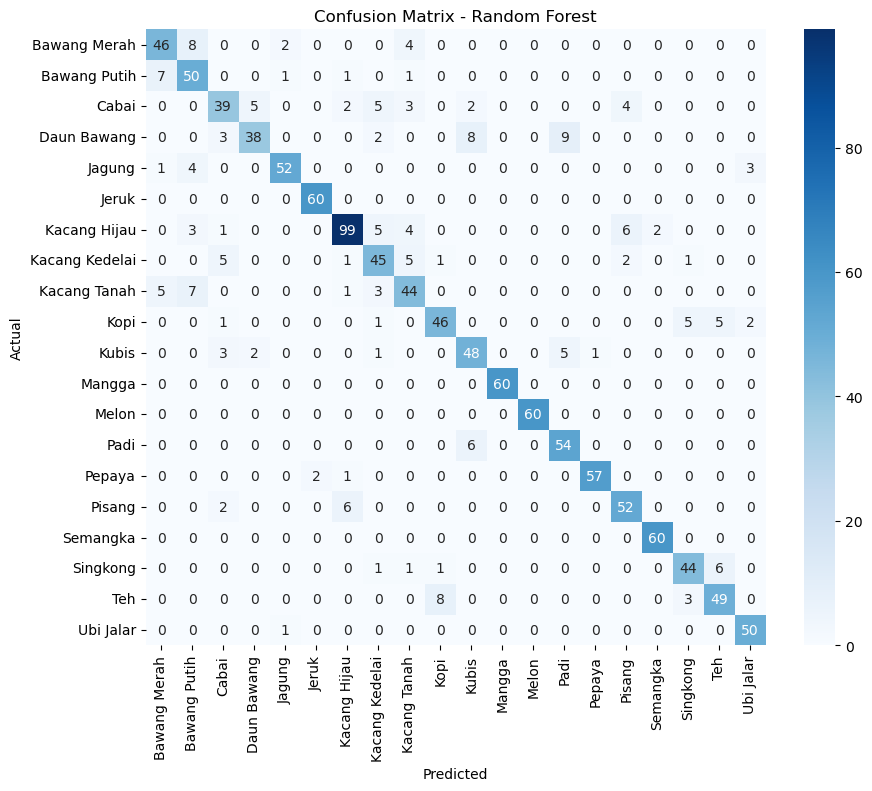

In [ ]:
cm = confusion_matrix(y_test, predicted_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_rf.classes_, yticklabels=model_rf.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

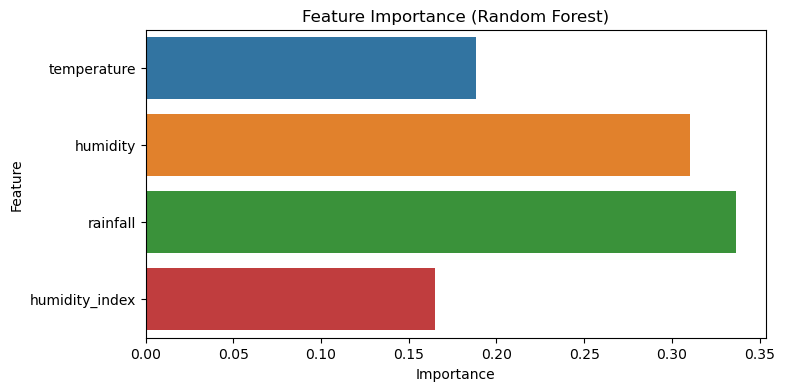

In [94]:
importances = best_rf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [95]:
print("\nSimulasi Prediksi pada Cuaca Ekstrem")
simulation_scenarios = [
    {"name": "Kemarau Ekstrem", "temperature": 34, "humidity": 35, "rainfall": 5},
    {"name": "Hujan Lebat", "temperature": 26, "humidity": 80, "rainfall": 300},
    {"name": "Dingin Lembap", "temperature": 19, "humidity": 90, "rainfall": 80},
    {"name": "Normal", "temperature": 28, "humidity": 75, "rainfall": 150}
]

for scenario in simulation_scenarios:
    hi = (scenario['temperature'] * scenario['humidity']) / 100
    input_arr = np.array([[scenario['temperature'], scenario['humidity'], scenario['rainfall'], hi]])
    pred = model_rf.predict(input_arr)
    print(f"{scenario['name']}: Prediksi tanaman yang cocok → {pred[0]}")


Simulasi Prediksi pada Cuaca Ekstrem
Kemarau Ekstrem: Prediksi tanaman yang cocok → Mangga
Hujan Lebat: Prediksi tanaman yang cocok → Padi
Dingin Lembap: Prediksi tanaman yang cocok → Jeruk
Normal: Prediksi tanaman yang cocok → Daun Bawang


c:\Users\ferdy\development\anaconda\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ferdy\development\anaconda\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ferdy\development\anaconda\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ferdy\development\anaconda\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [96]:
import joblib
joblib.dump(model_rf, '../../model/ModelClassifier.pkl')

['../../model/ModelClassifier.pkl']

In [52]:
numerical_features = ['temperature', 'humidity', 'rainfall', 'ph', 'nitrogen', 'phosphorous', 'potassium', 'carbon']

In [53]:
print("Calculating min/max ranges for each crop...")
crop_ranges = df_crop.groupby('label')[numerical_features].agg(['min', 'max'])

soil_texture = df_crop.groupby('label')['soil'].agg(lambda x: np.array(x.unique()))

Calculating min/max ranges for each crop...


In [54]:
crop_ranges.columns = ['_'.join(col).strip() for col in crop_ranges.columns.values]
crop_ranges = crop_ranges.reset_index()

In [55]:
harvest_time_map = {
    'Padi': 105,             # BBSDLP – Varietas Inpari & Ciherang: 100–110 HST
    'Jagung': 90,            # Balitsereal – Jagung hibrida: 85–95 HST
    'Semangka': 65,          # Balitkabi – Dataran rendah: 60–70 HST
    'Melon': 70,             # Balitsa – 65–75 HST tergantung varietas
    'Pepaya': 180,           # Litbang Hortikultura – 5–6 bulan awal panen buah
    'Mangga': 150,           # FAO & Litbang Buah – tanaman tahunan, panen mulai 2–3 tahun, buah tiap 150 hari dari bunga
    'Teh': 540,              # Tidak umum di DIY, Sekitar 18 bulan setelah tanam (sumber: PTPN VIII, BBPTP)
    'Pisang': 270,           # BPTP DIY – 9–12 bulan tergantung jenis
    'Jeruk': 240,            # BBPP Lembang – 8 bulan dari tanam atau 180 hari dari bunga
    'Kopi': 180,             # BPTP Jogja – tanaman tahunan, panen awal sekitar 2 tahun, setelah itu siklus 6 bulan
    'Ubi Jalar': 100,        # Balitkabi – Panen antara 90–110 HST
    'Singkong': 210,         # Litbang Kementan – Umur panen 7–9 bulan tergantung varietas
    'Kacang Kedelai': 85,    # Grobogan varietas – 80–90 HST (Balitkabi)
    'Kacang Hijau': 65,      # Litbang Kementan – 60–70 HST, tanaman sela paska padi
    'Kacang Tanah': 90,      # BPTP DIY – umur panen 85–95 HST, cocok lahan kering
    'Bawang Merah': 60,      # BBPP Ketindan – 55–70 HST, tergantung dataran
    'Bawang Putih': 110,     # BBPPTP – ±3,5 bulan (100–120 hari) di dataran tinggi
    'Cabai': 80,             # BBPPTP – panen mulai 70–80 HST, lalu berulang
    'Daun Bawang': 55,       # BPTP Jogja – Panen mulai umur 50–60 hari
    'Kubis': 90              # Balitsa – Panen 85–95 HST di dataran tinggi seperti Kaliurang
}

# References
# BBSDLP – Badan Litbang Sumber Daya Lahan Pertanian
# BPTP DIY – Balai Pengkajian Teknologi Pertanian Daerah Istimewa Yogyakarta
# Balitkabi – Balai Penelitian Tanaman Aneka Kacang dan Umbi
# BBPPTP – Balai Besar Pengembangan Pengujian Tanaman Pangan
# Balitsa – Balai Penelitian Tanaman Sayuran
# FAO – Food and Agriculture Organization
# Litbang Hortikultura – Kementerian Pertanian RI
# PTPN VIII – Perusahaan teh dan kopi nasional

In [56]:
crop_ranges['estimated_time'] = crop_ranges['label'].map(harvest_time_map)

In [57]:
crop_ranges.dropna(subset=['estimated_time'], inplace=True)
crop_ranges['estimated_time'] = crop_ranges['estimated_time'].astype(int)

In [58]:
print("\nGenerated Crop Recommendation Ranges:")
print(crop_ranges.head())


Generated Crop Recommendation Ranges:
          label  temperature_min  temperature_max  humidity_min  humidity_max  \
0  Bawang Merah        23.694723        32.346509     59.449088     75.331539   
1  Bawang Putih        22.830357        30.255904     64.433012     75.959301   
2         Cabai        23.617589        32.469735     69.137846     85.420081   
3   Daun Bawang        21.919623        30.359124     69.559519     90.153595   
4        Jagung        17.857768        26.425985     55.525688     74.561120   

   rainfall_min  rainfall_max    ph_min    ph_max  nitrogen_min  nitrogen_max  \
0     29.583201    100.345936  5.964498  6.813361       77.2900      120.5700   
1     39.211750    109.708641  6.434703  7.556169       67.0100      112.4700   
2     99.544735    247.997427  5.421026  6.838485       97.2500      151.0600   
3    149.328030    300.562683  5.916423  7.019510       58.0700       92.8500   
4     61.334825    110.404112  5.490198  6.952409       51.4895      

In [59]:
import pymysql

DB_CONFIG = {
    'host': 'localhost',
    'port': 3306,
    'user': 'root',
    'password': '',
    'database': 'gis_system'   
}

try:
    conn = pymysql.connect(**DB_CONFIG)
    cursor = conn.cursor()
    print("Berhasil terhubung ke database MySQL")
except pymysql.MySQLError as e:
    print(f"Gagal terhubung ke database MySQL: {e}")

Gagal terhubung ke database MySQL: (2003, "Can't connect to MySQL server on 'localhost' ([WinError 10061] No connection could be made because the target machine actively refused it)")


In [60]:
insert_or_update_query = """
INSERT INTO kondisi_tanaman (
    label, temperature_min, temperature_max, humidity_min, humidity_max, 
    rainfall_min, rainfall_max, ph_min, ph_max, nitrogen_min, nitrogen_max, 
    phosphorous_min, phosphorous_max, potassium_min, potassium_max, 
    carbon_min, carbon_max, soil_texture, estimated_time
) 
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
ON DUPLICATE KEY UPDATE
    temperature_min = VALUES(temperature_min),
    temperature_max = VALUES(temperature_max),
    humidity_min = VALUES(humidity_min),
    humidity_max = VALUES(humidity_max),
    rainfall_min = VALUES(rainfall_min),
    rainfall_max = VALUES(rainfall_max),
    ph_min = VALUES(ph_min),
    ph_max = VALUES(ph_max),
    nitrogen_min = VALUES(nitrogen_min),
    nitrogen_max = VALUES(nitrogen_max),
    phosphorous_min = VALUES(phosphorous_min),
    phosphorous_max = VALUES(phosphorous_max),
    potassium_min = VALUES(potassium_min),
    potassium_max = VALUES(potassium_max),
    carbon_min = VALUES(carbon_min),
    carbon_max = VALUES(carbon_max),
    soil_texture = VALUES(soil_texture),
    estimated_time = VALUES(estimated_time)
"""

crop_ranges['soil_texture'] = soil_texture.reindex(crop_ranges['label']).values
crop_ranges['soil_texture'] = crop_ranges['soil_texture'].apply(lambda x: ', '.join(map(str, x)) if isinstance(x, np.ndarray) else x)

data_to_insert = []
for _, row in crop_ranges.iterrows():
    data_to_insert.append((
        row['label'],
        row['temperature_min'], row['temperature_max'],
        row['humidity_min'], row['humidity_max'],
        row['rainfall_min'], row['rainfall_max'],
        row['ph_min'], row['ph_max'],
        row['nitrogen_min'], row['nitrogen_max'],
        row['phosphorous_min'], row['phosphorous_max'],
        row['potassium_min'], row['potassium_max'],
        row['carbon_min'], row['carbon_max'],
        row['soil_texture'],
        row['estimated_time']
    ))

if not data_to_insert:
    print("Tidak ada data yang akan dimasukkan atau diupdate ke tabel.")
else:
    try:
        print(f"Jumlah data yang akan dimasukkan/diperbarui: {len(data_to_insert)}")
        cursor.executemany(insert_or_update_query, data_to_insert)
        conn.commit()
        print(f"{cursor.rowcount} baris berhasil dimasukkan/diperbarui ke tabel kondisi_tanaman.")
    except Exception as e:
        print(f"Terjadi error saat menyimpan data: {e}")
        conn.rollback()


Jumlah data yang akan dimasukkan/diperbarui: 20
Terjadi error saat menyimpan data: name 'cursor' is not defined


NameError: name 'conn' is not defined